---
# FODO cell and xsuite comparison
---

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


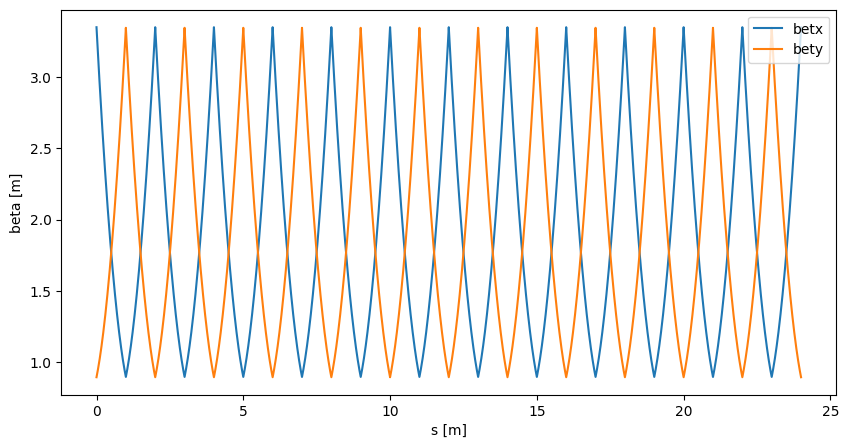

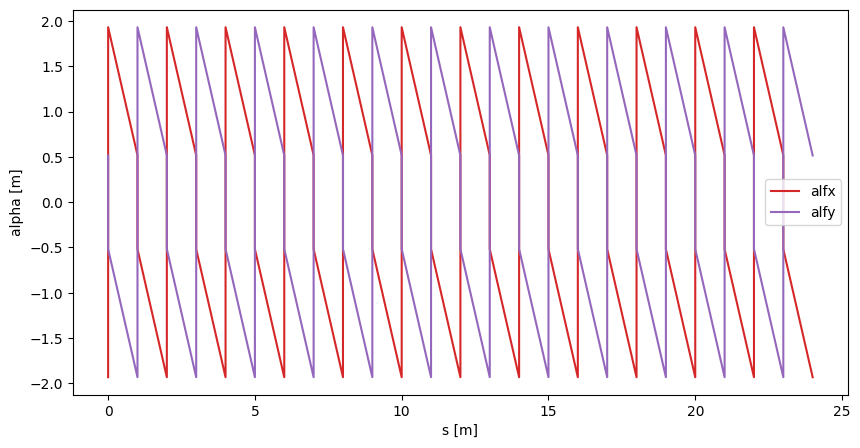

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import nafflib
import pytori as pt
import pytori.plotting as ptplt

import xtrack as xt
import xobjects as xo


# CELL parameters
#-----------------------
L       = 1                 #-- drift length
k       = 2/np.sqrt(3)      #-- focusing strength
dk      = 0.001*k           #-- to split x-y tunes
supP    = 12                 #-- superperiods
divs    = 100               #-- drift divisions (for visualization)
#-----------------------


# ELEMENTS
#=========================================================================================
elements = {}
for n in range(supP):
    cell = {
            f'entry.{n}'        : xt.Marker(),
            f'QF.{n}'           : xt.Multipole(knl=[0,k],ksl=[0,0],length=0),
            **{f'O1.{n}.{i}'    : xt.Drift(length=L/divs) for i in range(divs)},
            f'QD.{n}'           : xt.Multipole(knl=[0,-(k+dk)],ksl=[0,0],length=0),
            **{f'O2.{n}.{i}'    : xt.Drift(length=L/divs) for i in range(divs)},
        }
    elements.update(cell)
#=========================================================================================

# BEAM & XSUITE LINE
#=========================================================================================
nrj             = 7000e9
particle_ref    = xt.Particles(p0c=nrj, q0=1, mass0=xt.PROTON_MASS_EV)
context         = xo.ContextCpu(omp_num_threads='auto')
nemitt_x        = 2.5e-6
nemitt_y        = 2.5e-6
gemitt_x        = 1 if nemitt_x is None else ( nemitt_x / particle_ref.beta0[0] / particle_ref.gamma0[0])
gemitt_y        = 1 if nemitt_y is None else ( nemitt_y / particle_ref.beta0[0] / particle_ref.gamma0[0])
#-----------------------------------------------------------------------------------------
line = xt.Line(elements=elements)
line.particle_ref = particle_ref
line.build_tracker(_context=context)
line.freeze_longitudinal(True)
twiss       = line.twiss4d()
#=========================================================================================


plt.figure(figsize=(10,5))
plt.plot(twiss.s, twiss.betx, label='betx')
plt.plot(twiss.s, twiss.bety, label='bety')
plt.xlabel('s [m]')
plt.ylabel('beta [m]')
plt.legend()


plt.figure(figsize=(10,5))
plt.plot(twiss.s, twiss.alfx, label='alfx',color='C3')
plt.plot(twiss.s, twiss.alfy, label='alfy',color='C4')
plt.xlabel('s [m]')
plt.ylabel('alpha [m]')
plt.legend()

---
# Periodic torus transport
---

╭─────────────────────────────────────────────── Torus (FourierSeries) ────────────────────────────────────────────────╮
│                                                                                                                      │
│  ╭────────────────────────── x ──────────────────────────╮                                                           │
│  │                                                       │                                                           │
│  │   Index     Value                       Norm          │                                                           │
│  │   ( 1, 0)  -2.17495e-05 - 9.66899e-06j  2.38019e-05   │                                                           │
│  │   (-1, 0)  -1.17449e-05 - 9.66899e-06j  1.52129e-05   │                                                           │
│  │                                                       │                                                           │
│  ╰─────────────────────── terms=2 ───────────────────────╯                                                           │
│  ╭────────────────────────── y ──────────────────────────╮                                                           │
│  │                                                       │                                                           │
│  │   Index     Value                       Norm          │                                                           │
│  │   ( 0, 1)   1.83340e-05 + 4.99854e-06j  1.90032e-05   │                                                           │
│  │   ( 0,-1)   1.01851e-06 + 4.99854e-06j  5.10125e-06   │                                                           │
│  │                                                       │                                                           │
│  ╰─────────────────────── terms=2 ───────────────────────╯                                                           │
│                                                                                                                      │
╰─ dim=2, β₀=(1, 1, 1), (Ix,Iy)=(1.68e-10, 1.68e-10), max_order=None, max_terms=100, numerical_tol=None, backend='nump─╯


Phase advance from torus (arg(A0'/A0))	: 0.3500 [2pi]
Expected phase advance from twiss	: 2.3500 [2pi]


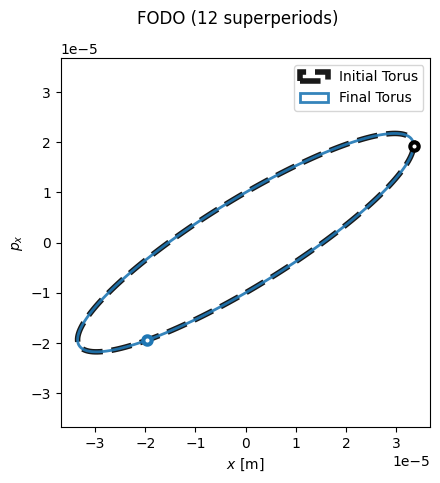

In [2]:
# Constructing matched torus from W-matrix (2D here)
x_sig  = 1
y_sig  = 1
nemitt_x = 2.5e-6
nemitt_y = 2.5e-6
torus0 = pt.Torus.linear_match(I=[(x_sig**2)/2,(y_sig**2)/2],
                               W_matrix=twiss.W_matrix[0],
                               nemitt_x=nemitt_x, 
                               nemitt_y=nemitt_y,
                               particle_on_co=twiss.particle_on_co)

# Tracking & plotting
torus = torus0.copy()
for ee,ee_name in zip(line.elements,line.element_names):
    if isinstance(ee,xt.Drift):
        torus = pt.transforms.drift(torus,ds=ee.length)
    elif isinstance(ee,xt.Multipole):
        torus = pt.transforms.multipole(torus,knl=ee.knl,ksl=ee.ksl)

# Printing torus
print(torus0)

# Extracting some info:
phase_diff  = pt.mathlib._tune_angle(torus.x[(1,0)]/torus0.x[(1,0)])
tune        = twiss.qx
print(f'Phase advance from torus (arg(A0\'/A0))\t: {phase_diff:.4f} [2pi]')
print(f'Expected phase advance from twiss\t: {tune:.4f} [2pi]')

# Plotting
plt.figure()
plt.suptitle(f'FODO ({supP} superperiods)')
ptplt.xloop(torus0,num_points=200,ls='--',edgecolor='k',alpha=0.9,lw=4,label='Initial Torus')
ptplt.xloop(torus,num_points=200,edgecolor='C0',alpha=0.9,lw=2,label='Final Torus')


# Showing phase advance
plt.plot(torus0.X(0), torus0.PX(0),'o',color='w',mec='k',mew=3)
plt.plot(torus.X(0), torus.PX(0),'o',color='w',mec='C0',mew=3)


plt.legend()
plt.axis('equal')
plt.gca().set_box_aspect(1) 
plt.xlabel(r'$x\ [\mathrm{m}]$');
plt.ylabel(r'$p_x$');



---
# Aribtrary shape
---

Let's show that arbitrary tori can also be transported. For this we start by considering a superellipse (which interpolates between an ellipse and a rectangle) to model a rectangualr level curve which could be obtained due to a collimator (with alfx=0).

##### NOTE: This is a thought experiment and this particular example may not have any relevant physical meaning

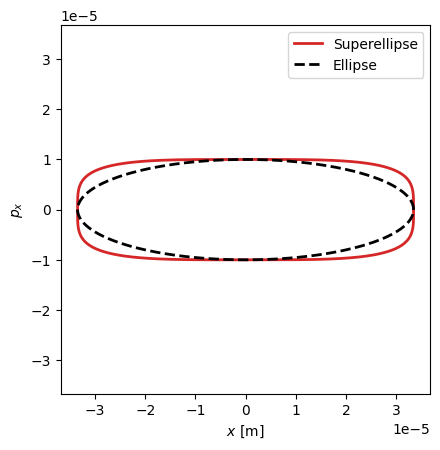

In [3]:

def superellipse(Tx,betx,gemitt_x, n=2, m=None, num=800):
    """
    Returns x(t), y(t) points of a (possibly anisotropic) superellipse:
        |x/a|^n + |px/b|^m = 1
    If n is None, the exponent is symmetric: n = m.
    """
    if m is None:
        m = n

    a = np.sqrt(betx*gemitt_x)
    b = np.sqrt(gemitt_x/betx)

    # Parametric definition
    x  = a * np.sign(np.cos(Tx)) * np.abs(np.cos(Tx))**(2/n)
    px = b * np.sign(np.sin(Tx)) * np.abs(np.sin(Tx))**(2/m)


    return x,px

Tx = np.linspace(0,2*np.pi,800)
plt.figure()

x_se, px_se = superellipse(Tx,betx=twiss.betx[0],gemitt_x=gemitt_x,n=4)
plt.plot(x_se,px_se,'-',color='C3',lw=2,label='Superellipse')   
x_se, px_se = superellipse(Tx,betx=twiss.betx[0],gemitt_x=gemitt_x,n=2)
plt.plot(x_se,px_se,'--',color='k',lw=2,label='Ellipse')        

plt.legend()
plt.axis('equal')
plt.gca().set_box_aspect(1) 
plt.xlabel(r'$x\ [\mathrm{m}]$');
plt.ylabel(r'$p_x$');


We can construct this torus numerically (via NAFF) by using a dummy strobscopic sampling:

╭─────────────────────────────────────────────── Torus (FourierSeries) ────────────────────────────────────────────────╮
│                                                                                                                      │
│  ╭───────────────────────── x ─────────────────────────╮                                                             │
│  │                                                     │                                                             │
│  │   Index   Value                       Norm          │                                                             │
│  │   ( 1)   -2.09609e-05 - 1.21018e-05j  2.42036e-05   │                                                             │
│  │   (-1)   -1.13192e-05 - 6.53512e-06j  1.30702e-05   │                                                             │
│  │   (-3)    2.99442e-06 + 1.72882e-06j  3.45766e-06   │                                                             │
│  │   ( 3)    1.61726e-06 + 9.33722e-07j  1.86745e-06   │                                                             │
│  │   ( 5)   -1.36110e-06 - 7.85837e-07j  1.57166e-06   │                                                             │
│  │   (-7)    8.16663e-07 + 4.71493e-07j  9.42997e-07   │                                                             │
│  │   (-5)   -7.35413e-07 - 4.24592e-07j  8.49183e-07   │                                                             │
│  │   ( 9)   -5.58764e-07 - 3.22610e-07j  6.45209e-07   │                                                             │
│  │   ( 7)    4.41576e-07 + 2.54943e-07j  5.09888e-07   │                                                             │
│  │   (-11)   4.13005e-07 + 2.38441e-07j  4.76893e-07   │                                                             │
│  │   ...    ...                          ...           │                                                             │
│  │                                                     │                                                             │
│  ╰───────────────────── terms=165 ─────────────────────╯                                                             │
│                                                                                                                      │
╰────── dim=1, β₀=(1, 1, 1), (Ix)=(1.98e-10), max_order=None, max_terms=500, numerical_tol=None, backend='numpy' ──────╯

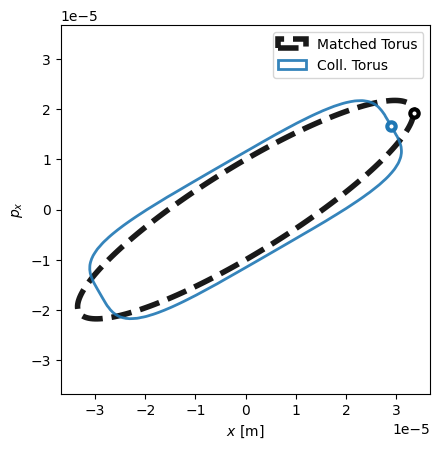

In [4]:
# Generating dummy signal
#============================================================================
num_turns = int(1e5)
fx  = 1/2/np.sqrt(2)
Tx  = 2*np.pi*fx*np.arange(num_turns)

x_se, px_se = superellipse(Tx,betx=twiss.betx[0],gemitt_x=gemitt_x,n=4)
#----------------------------------------------------------------------------

# Extracting harmonics:
#============================================================================
n_harm  = 200
w_order = 4
Ax,Qx   = nafflib.harmonics(x_se, px_se,num_harmonics = n_harm,window_order=w_order)
#============================================================================

# Indexing harmonics
#============================================================================
max_n       = 90 #(high numbers needed in 2D..)
max_alias   = 50
warning_tol = np.inf #Disable warnings
Qvec    = [Qx[0]]
nx      = nafflib.linear_combinations(Qx,Qvec = Qvec,max_n=max_n,max_alias=max_alias,warning_tol=warning_tol)
#============================================================================

# Building torus (2D-torus)
#============================================================================
coll_torus = pt.Torus.from_naff(n=[nx],A=[Ax],max_terms=500)


# Finally, we rotate the torus to align with our phase space
tilt = -2*np.pi*pt.mathlib._tune_angle(1/(torus0.x[(1,0)] + torus0.x[(-1,0)]))
coll_torus.x *= np.exp(1j*tilt)

#Display
print(coll_torus)


# Plotting
plt.figure()
ptplt.xloop(torus0,num_points=200,ls='--',edgecolor='k',alpha=0.9,lw=4,label='Matched Torus')
ptplt.xloop(coll_torus,num_points=200,edgecolor='C0',alpha=0.9,lw=2,label='Coll. Torus')


# Showing phase advance
plt.plot(torus0.X(0), torus0.PX(0),'o',color='w',mec='k',mew=3)
plt.plot(coll_torus.X(0), coll_torus.PX(0),'o',color='w',mec='C0',mew=3)


plt.legend()
plt.axis('equal')
plt.gca().set_box_aspect(1) 
plt.xlabel(r'$x\ [\mathrm{m}]$');
plt.ylabel(r'$p_x$');



Let's now see how this shape is tranported through the FODO cell:

╭─────────────────────────────────────────────── Torus (FourierSeries) ────────────────────────────────────────────────╮
│                                                                                                                      │
│  ╭───────────────────────── x ─────────────────────────╮                                                             │
│  │                                                     │                                                             │
│  │   Index   Value                       Norm          │                                                             │
│  │   ( 1)    1.59174e-06 + 2.84244e-05j  2.84690e-05   │                                                             │
│  │   (-1)   -1.73772e-05 - 9.67123e-06j  1.98871e-05   │                                                             │
│  │   (-3)   -2.27667e-07 - 4.06024e-06j  4.06662e-06   │                                                             │
│  │   ( 3)    2.48234e-06 + 1.38107e-06j  2.84066e-06   │                                                             │
│  │   ( 5)    1.03796e-07 + 1.84506e-06j  1.84798e-06   │                                                             │
│  │   (-5)   -1.12817e-06 - 6.27093e-07j  1.29074e-06   │                                                             │
│  │   (-7)   -6.26642e-08 - 1.10649e-06j  1.10826e-06   │                                                             │
│  │   ( 7)    6.76745e-07 + 3.75503e-07j  7.73942e-07   │                                                             │
│  │   ( 9)    3.68121e-08 + 7.66235e-07j  7.67119e-07   │                                                             │
│  │   (-11)  -2.58322e-08 - 5.68440e-07j  5.69026e-07   │                                                             │
│  │   ...    ...                          ...           │                                                             │
│  │                                                     │                                                             │
│  ╰───────────────────── terms=181 ─────────────────────╯                                                             │
│                                                                                                                      │
╰────── dim=1, β₀=(1, 1, 1), (Ix)=(1.98e-10), max_order=None, max_terms=500, numerical_tol=None, backend='numpy' ──────╯

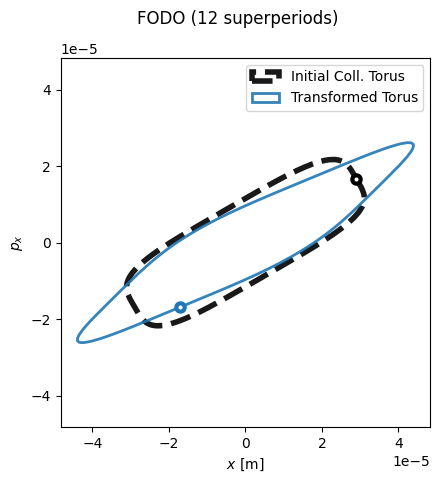

In [5]:

# Tracking & plotting
torus = coll_torus.copy()
for ee,ee_name in zip(line.elements,line.element_names):
    if isinstance(ee,xt.Drift):
        torus = pt.transforms.drift(torus,ds=ee.length)
    elif isinstance(ee,xt.Multipole):
        torus = pt.transforms.multipole(torus,knl=ee.knl,ksl=ee.ksl)


print(torus)

# Plotting
plt.figure()
plt.suptitle(f'FODO ({supP} superperiods)')
ptplt.xloop(coll_torus,num_points=200,ls='--',edgecolor='k',alpha=0.9,lw=4,label='Initial Coll. Torus')
ptplt.xloop(torus,num_points=200,edgecolor='C0',alpha=0.9,lw=2,label='Transformed Torus')


# Showing phase advance
plt.plot(coll_torus.X(0), coll_torus.PX(0),'o',color='w',mec='k',mew=3)
plt.plot(torus.X(0), torus.PX(0),'o',color='w',mec='C0',mew=3)


plt.legend()
plt.axis('equal')
plt.gca().set_box_aspect(1) 
plt.xlabel(r'$x\ [\mathrm{m}]$');
plt.ylabel(r'$p_x$');

